In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [46]:
df=pd.read_csv('churn_data.csv')

In [47]:
df.head() #this will display the first 5 rows

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,555,27,Female,41,81.41,Month-to-Month,NaN,713.20,No,Yes
1,883,54,Male,35,94.33,One-Year,Fiber Optic,7562.29,Yes,Yes
2,101,40,Male,31,49.01,Month-to-Month,Fiber Optic,1481.22,No,No
3,329,55,Male,66,77.29,Month-to-Month,DSL,980.43,No,Yes
4,922,50,Female,3,34.54,Month-to-Month,DSL,5242.88,No,Yes


In [48]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3347 entries, 0 to 3346
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       3347 non-null   int64  
 1   Age              3347 non-null   int64  
 2   Gender           3347 non-null   object 
 3   Tenure           3347 non-null   int64  
 4   MonthlyCharges   3347 non-null   float64
 5   ContractType     3347 non-null   object 
 6   InternetService  2360 non-null   object 
 7   TotalCharges     3347 non-null   float64
 8   TechSupport      3347 non-null   object 
 9   Churn            3347 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 261.6+ KB


In [49]:
df.isnull().sum()


CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    987
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [50]:
df['InternetService'].value_counts()

InternetService
Fiber Optic    1255
DSL            1105
Name: count, dtype: int64

In [51]:
df['InternetService']=df['InternetService'].fillna('')

In [52]:
df.isnull().sum()


CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [53]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,555,27,Female,41,81.41,Month-to-Month,,713.20,No,Yes
1,883,54,Male,35,94.33,One-Year,Fiber Optic,7562.29,Yes,Yes
2,101,40,Male,31,49.01,Month-to-Month,Fiber Optic,1481.22,No,No
3,329,55,Male,66,77.29,Month-to-Month,DSL,980.43,No,Yes
4,922,50,Female,3,34.54,Month-to-Month,DSL,5242.88,No,Yes


In [54]:
df.duplicated().sum()

0

In [55]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,3347.000000,3347.000000,3347.000000,3347.000000,3347.000000
mean,1401.770541,44.968629,24.271586,71.063107,1601.159101
std,2657.859884,10.230191,25.205326,25.867795,1692.943156
min,1.000000,12.000000,0.000000,25.210000,0.000000
25%,278.000000,38.000000,6.000000,49.050000,402.030000
50%,563.000000,45.000000,16.000000,68.100000,1033.270000
75%,843.500000,52.000000,33.000000,92.360000,2267.460000
max,9346.000000,83.000000,122.000000,119.960000,12416.250000


In [56]:
numerical_columns=df.select_dtypes(include=['number']) #This will select only numerical value datatypes
# numerical_columns=df.select_dtypes(exclude='object') This will also select numerical values, but it will also take in other datatypes that are NOT object hence this will not work out

In [57]:
numerical_columns

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,555,27,41,81.41,713.20
1,883,54,35,94.33,7562.29
2,101,40,31,49.01,1481.22
3,329,55,66,77.29,980.43
4,922,50,3,34.54,5242.88
...,...,...,...,...,...
3342,654,50,9,60.90,467.35
3343,900,60,17,33.53,844.16
3344,642,46,36,119.65,2121.24
3345,861,47,55,78.63,4324.65


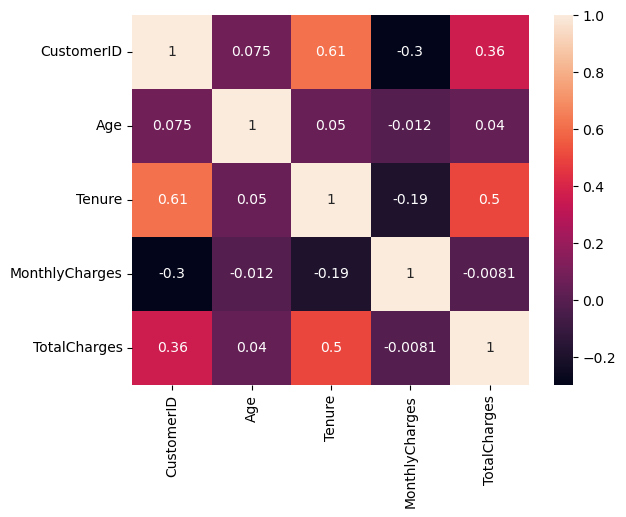

In [58]:
#This will help us see which features are highly co related and which are not hence helping us select the right features
sns.heatmap(numerical_columns.corr(),annot=True)
plt.savefig("images/Correlation.png", bbox_inches="tight")
plt.show()
plt.close()


In [59]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,555,27,Female,41,81.41,Month-to-Month,,713.20,No,Yes
1,883,54,Male,35,94.33,One-Year,Fiber Optic,7562.29,Yes,Yes
2,101,40,Male,31,49.01,Month-to-Month,Fiber Optic,1481.22,No,No
3,329,55,Male,66,77.29,Month-to-Month,DSL,980.43,No,Yes
4,922,50,Female,3,34.54,Month-to-Month,DSL,5242.88,No,Yes
...,...,...,...,...,...,...,...,...,...,...
3342,654,50,Male,9,60.90,One-Year,DSL,467.35,Yes,Yes
3343,900,60,Male,17,33.53,Month-to-Month,Fiber Optic,844.16,No,Yes
3344,642,46,Female,36,119.65,Month-to-Month,,2121.24,Yes,Yes
3345,861,47,Male,55,78.63,Month-to-Month,,4324.65,No,Yes


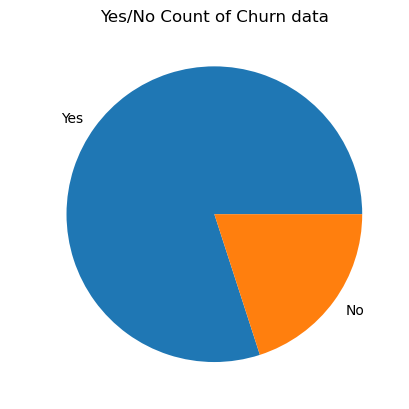

In [60]:
df['Churn'].value_counts().plot(kind='pie')   #data analysis of the churn column
plt.title("Yes/No Count of Churn data")
plt.ylabel(" ")
plt.savefig("images/Yes_No_count.png", bbox_inches="tight")
plt.show()
plt.close()
#Verdict- Majority of our customers churn out to give a YES output

### Now we will group the data by Churn that is YES OR NO and then calculate what they pay on average

In [61]:

df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     59.251358
Yes    74.019354
Name: MonthlyCharges, dtype: float64

In [62]:
df.groupby(['Churn','Gender'])['MonthlyCharges'].mean()

Churn  Gender
No     Female    58.913361
       Male      59.636869
Yes    Female    73.496575
       Male      74.638075
Name: MonthlyCharges, dtype: float64

In [63]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,555,27,Female,41,81.41,Month-to-Month,,713.20,No,Yes
1,883,54,Male,35,94.33,One-Year,Fiber Optic,7562.29,Yes,Yes
2,101,40,Male,31,49.01,Month-to-Month,Fiber Optic,1481.22,No,No
3,329,55,Male,66,77.29,Month-to-Month,DSL,980.43,No,Yes
4,922,50,Female,3,34.54,Month-to-Month,DSL,5242.88,No,Yes


In [64]:
df.groupby("Churn")['Age'].mean()

Churn
No     45.564179
Yes    44.819574
Name: Age, dtype: float64

In [65]:
df.groupby("ContractType")["MonthlyCharges"].mean()

ContractType
Month-to-Month    74.141593
One-Year          70.030946
Two-Year          66.613436
Name: MonthlyCharges, dtype: float64

In [66]:
df.groupby("ContractType")["MonthlyCharges"].mean().dtype

dtype('float64')

### We can see that , Longer the contract cheaper the mean monthly charges are

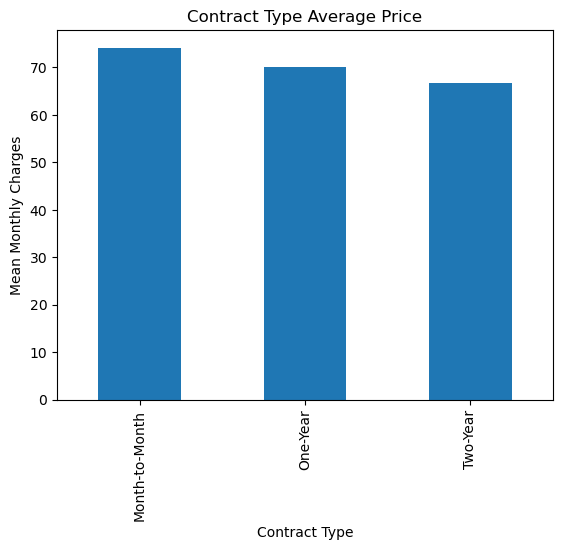

In [67]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind='bar')
plt.title("Contract Type Average Price")
plt.ylabel("Mean Monthly Charges")
plt.xlabel("Contract Type")
plt.savefig("images/Contract_type_data_counts.png", bbox_inches="tight")
plt.show()
plt.close()

In [68]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,555,27,Female,41,81.41,Month-to-Month,,713.20,No,Yes
1,883,54,Male,35,94.33,One-Year,Fiber Optic,7562.29,Yes,Yes
2,101,40,Male,31,49.01,Month-to-Month,Fiber Optic,1481.22,No,No
3,329,55,Male,66,77.29,Month-to-Month,DSL,980.43,No,Yes
4,922,50,Female,3,34.54,Month-to-Month,DSL,5242.88,No,Yes
...,...,...,...,...,...,...,...,...,...,...
3342,654,50,Male,9,60.90,One-Year,DSL,467.35,Yes,Yes
3343,900,60,Male,17,33.53,Month-to-Month,Fiber Optic,844.16,No,Yes
3344,642,46,Female,36,119.65,Month-to-Month,,2121.24,Yes,Yes
3345,861,47,Male,55,78.63,Month-to-Month,,4324.65,No,Yes


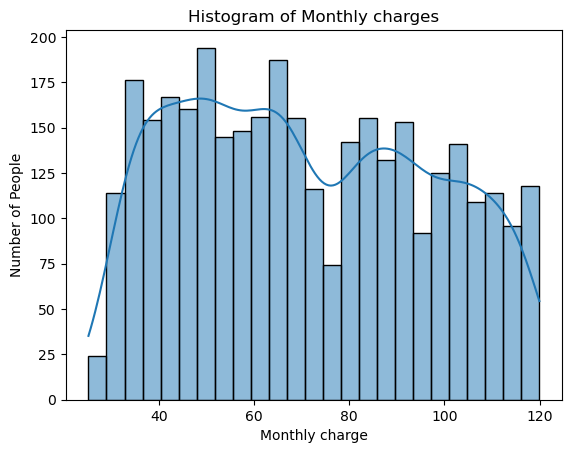

In [69]:
sns.histplot(df['MonthlyCharges'],bins=25,kde=True)
plt.title("Histogram of Monthly charges")
plt.ylabel("Number of People")
plt.xlabel("Monthly charge")
plt.savefig("images/Monthly_charges_histogram.png", bbox_inches="tight")
plt.show()
plt.close()

### -> From this we conclude that majority of people pay average or less monthly charges whereas a very small % pay high monthly charges. Churning of these high paying customers will lead to major revenue loss

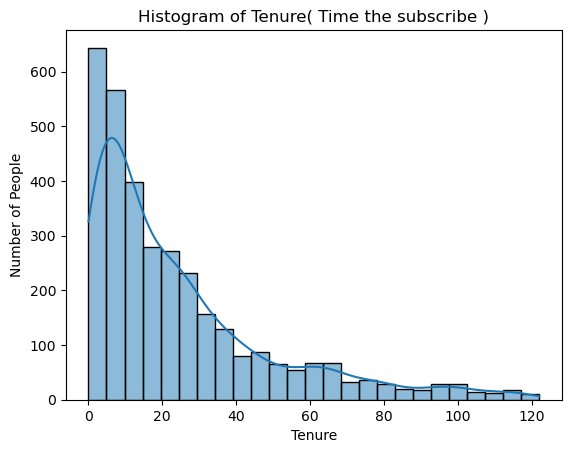

In [70]:
sns.histplot(df['Tenure'],bins=25,kde=True)
plt.title("Histogram of Tenure( Time the subscribe )")
plt.ylabel("Number of People")
plt.xlabel("Tenure")
plt.savefig("images/Tenure_histogram.png", bbox_inches="tight")
plt.show()
plt.close()

### -> We can conclude from this that many many people have a very less tenure before they churn (Leave/unsubscribe) from the service.


In [71]:
print(df['Churn'].value_counts())

Churn
Yes    2677
No      670
Name: count, dtype: int64
